In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle
from matplotlib.transforms import Affine2D
from matplotlib.axes import Axes

text_style = dict(
    horizontalalignment="right",
    verticalalignment="center",
    fontsize=12,
    fontfamily="monospace",
)
marker_style = dict(
    linestyle=":",
    color="0.8",
    markersize=10,
    markerfacecolor="tab:blue",
    markeredgecolor="tab:blue",
)


def format_axes(ax: Axes):
    ax.margins(0.2)
    ax.set_axis_off()
    ax.invert_yaxis()


def split_list(a_list):
    i_half = len(a_list) // 2
    return a_list[:i_half], a_list[i_half:]

#### Unfilled Markers

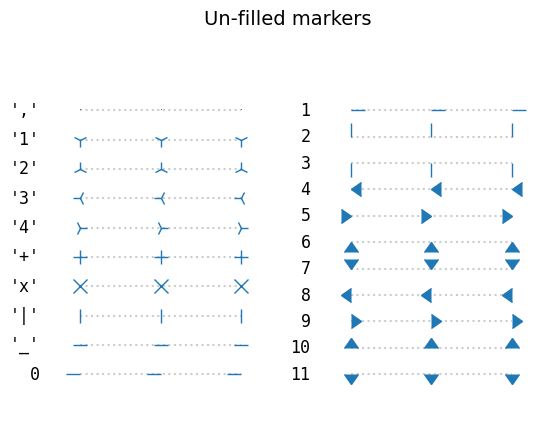

In [13]:
fig, axs = plt.subplots(ncols=2)
fig.suptitle("Un-filled markers", fontsize=14)

# Filter out filled markers and marker settings that do nothing.
unfilled_markers = [m for m, func in Line2D.markers.items() if func != "nothing" and m not in Line2D.filled_markers]

for ax, markers in zip(axs, split_list(unfilled_markers)):
    for y, marker in enumerate(markers):
        ax.text(-0.5, y, repr(marker), **text_style)
        ax.plot([y] * 3, marker=marker, **marker_style)
    format_axes(ax)

#### Filled Markers

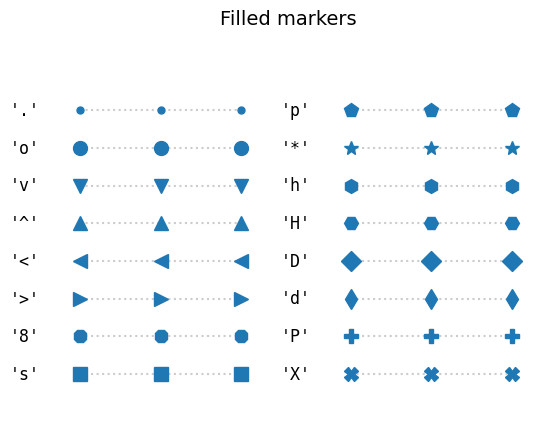

In [14]:
fig, axs = plt.subplots(ncols=2)
fig.suptitle("Filled markers", fontsize=14)

for ax, markers in zip(axs, split_list(Line2D.filled_markers)):
    for y, marker in enumerate(markers):
        ax.text(-0.5, y, repr(marker), **text_style)
        ax.plot([y] * 3, marker=marker, **marker_style)
    format_axes(ax)

#### Marker Fill Styles

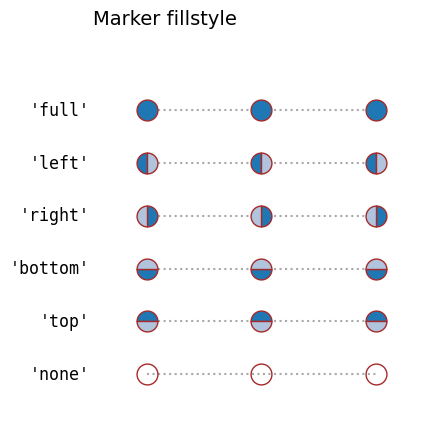

In [15]:
fig, ax = plt.subplots()
fig.suptitle("Marker fillstyle", fontsize=14)
fig.subplots_adjust(left=0.4)

filled_marker_style = dict(
    marker="o",
    linestyle=":",
    markersize=15,
    color="darkgrey",
    markerfacecolor="tab:blue",
    markerfacecoloralt="lightsteelblue",
    markeredgecolor="brown",
)

for y, fill_style in enumerate(Line2D.fillStyles):
    ax.text(-0.5, y, repr(fill_style), **text_style)
    ax.plot([y] * 3, fillstyle=fill_style, **filled_marker_style)
format_axes(ax)

#### Markers created from TeX Symbols

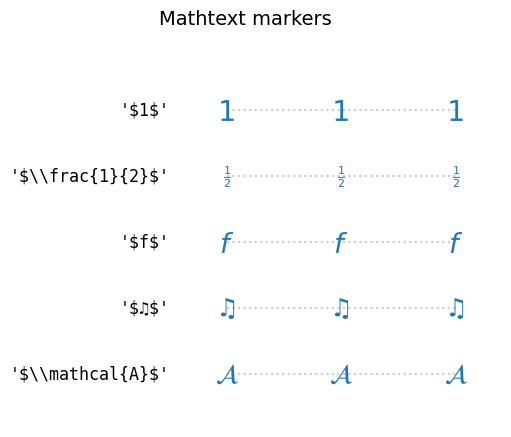

In [18]:
fig, ax = plt.subplots()
fig.suptitle("Mathtext markers", fontsize=14)
fig.subplots_adjust(left=0.4)

marker_style.update(markeredgecolor="none", markersize=15)
markers = [
    "$1$",
    r"$\frac{1}{2}$",
    "$f$",
    "$\u266b$",
    r"$\mathcal{A}$",
]

for y, marker in enumerate(markers):
    ax.text(-0.5, y, repr(marker).replace("$", r"\$"), **text_style)
    ax.plot([y] * 3, marker=marker, **marker_style)
format_axes(ax)

#### Markers created from Paths

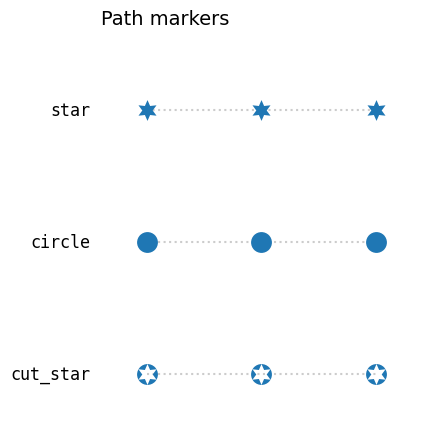

In [ ]:
import numpy as np
import matplotlib.path as mpath

star = mpath.Path.unit_regular_star(6)
circle = mpath.Path.unit_circle()

# Concatenate the circle with an internal coutout of the star
cut_star = mpath.Path(
    vertices=np.concatenate([circle.vertices, star.vertices[::-1, ...]]),
    codes=np.concatenate([circle.codes, star.codes]),
)

fig, ax = plt.subplots()
fig.suptitle("Path markers", fontsize=14)
fig.subplots_adjust(left=0.4)

markers = {"star": star, "circle": circle, "cut_star": cut_star}

for y, (name, marker) in enumerate(markers.items()):
    ax.text(-0.5, y, name, **text_style)
    ax.plot([y] * 3, marker=marker, **marker_style)
format_axes(ax)


#### Advanced Marker Modifications with Transform

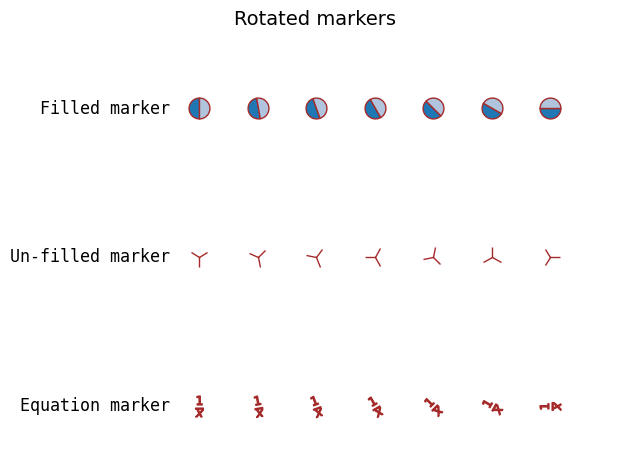

In [27]:
common_style = {k: v for k, v in filled_marker_style.items() if k != "marker"}
angles = [0, 10, 20, 30, 45, 60, 90]

fig, ax = plt.subplots()
fig.suptitle("Rotated markers", fontsize=14)

ax.text(-0.5, 0, "Filled marker", **text_style)
for x, theta in enumerate(angles):
    t = Affine2D().rotate_deg(theta)
    ax.plot(x, 0, marker=MarkerStyle("o", "left", t), **common_style)

ax.text(-0.5, 1, "Un-filled marker", **text_style)
for x, theta in enumerate(angles):
    t = Affine2D().rotate_deg(theta)
    ax.plot(x, 1, marker=MarkerStyle("1", "left", t), **common_style)

ax.text(-0.5, 2, "Equation marker", **text_style)
for x, theta in enumerate(angles):
    t = Affine2D().rotate_deg(theta)
    eq = r"$\frac{1}{x}$"
    ax.plot(x, 2, marker=MarkerStyle(eq, "left", t), **common_style)

format_axes(ax)
fig.tight_layout()

#### Setting Marker Cap Style and Join Style

In [28]:
from matplotlib.markers import CapStyle, JoinStyle

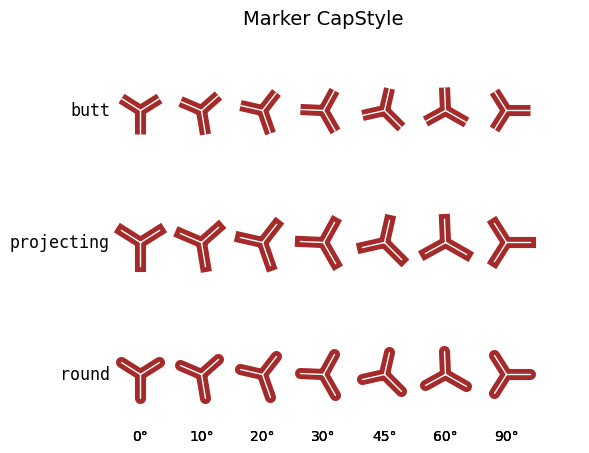

In [31]:
marker_inner = dict(
    markersize=35,
    markerfacecolor="tab:blue",
    markerfacecoloralt="lightsteelblue",
    markeredgecolor="brown",
    markeredgewidth=8,
)
marker_outer = dict(
    markersize=35,
    markerfacecolor="tab:blue",
    markerfacecoloralt="lightsteelblue",
    markeredgecolor="white",
    markeredgewidth=1,
)
fig, ax = plt.subplots()
fig.suptitle("Marker CapStyle", fontsize=14)
fig.subplots_adjust(left=0.1)

for y, cap_style in enumerate(CapStyle):
    ax.text(-0.5, y, cap_style.name, **text_style)
    for x, theta in enumerate(angles):
        t = Affine2D().rotate_deg(theta)
        m = MarkerStyle("1", transform=t, capstyle=cap_style)
        ax.plot(x, y, marker=m, **marker_inner)
        ax.plot(x, y, marker=m, **marker_outer)
        ax.text(x, len(CapStyle) - 0.5, f"{theta}°", ha="center")
format_axes(ax)